In [21]:
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [20]:
#use appropriate file path
file_path = r"dataset/Electromyography Signal Dataset for Controlling Lower Limb Prostheses.xlsx"

In [3]:
emg_data_dict = pd.read_excel(file_path, sheet_name=None)

In [4]:
data = []

In [5]:
drop_count = 0
for sheet_name, df in emg_data_dict.items():
    
    df = df.dropna(axis=1, how='all')
    drop_count+=1
    df['Label'] = sheet_name
    df.columns = ['Raw_EMG', 'Label']
    data.append(df)
drop_count

3

In [6]:
emg_df = pd.concat(data, ignore_index=True)

In [7]:
print("\nDataset successfully loaded and labeled!")
print(f"Total data points: {len(emg_df)}")
print("\nDistribution of classes:")
print(emg_df['Label'].value_counts())


Dataset successfully loaded and labeled!
Total data points: 161740

Distribution of classes:
Label
leg down    110874
leg move     37558
leg up       13308
Name: count, dtype: int64


In [8]:
def preprocess_emg(signal, fs=1000):
    """
    Cleans raw EMG data using a standard 4-step pipeline.
    Assuming a sampling frequency (fs) of 1000 Hz.
    """
    # Calculate the Nyquist frequency
    nyq = 0.5 * fs
    
    # 1. Bandpass Filter (20Hz - 450Hz)
    low = 20.0 / nyq
    high = 450.0 / nyq
    b_band, a_band = butter(4, [low, high], btype='band')
    bandpassed = filtfilt(b_band, a_band, signal)
    
    # 2. Notch Filter (50Hz power-line noise)
    notch_freq = 50.0 / nyq
    b_notch, a_notch = iirnotch(notch_freq, 30.0)
    notched = filtfilt(b_notch, a_notch, bandpassed)
    
    # 3. Rectification (Absolute value)
    rectified = np.abs(notched)
    
    # 4. Smoothing (Low-pass filter at ~10Hz to create the linear envelope)
    low_smooth = 10.0 / nyq
    b_smooth, a_smooth = butter(4, low_smooth, btype='low')
    smoothed = filtfilt(b_smooth, a_smooth, rectified)
    
    return smoothed

In [9]:

emg_df['Raw_EMG'] = pd.to_numeric(emg_df['Raw_EMG'], errors='coerce')


emg_df = emg_df.dropna(subset=['Raw_EMG'])


emg_df['Clean_EMG'] = preprocess_emg(emg_df['Raw_EMG'])

print("Preprocessing complete! Here is a preview:")
print(emg_df.head())

Preprocessing complete! Here is a preview:
   Raw_EMG     Label  Clean_EMG
0      8.0  leg down   3.734894
1      5.0  leg down   4.448659
2     17.0  leg down   5.160048
3      3.0  leg down   5.867817
4     23.0  leg down   6.570730


In [10]:
def extract_features(window):
    """Calculates statistical time-domain features for a given window of EMG data."""
    return {
        'MAV': np.mean(np.abs(window)),
        'RMS': np.sqrt(np.mean(window**2)),
        'Variance': np.var(window),
        'Waveform_Length': np.sum(np.abs(np.diff(window)))
    }

In [11]:
window_size = 200
step_size = 100  # 100ms overlap to ensure no movement data is missed between chunks

feature_dataset = []

# Loop through each distinct movement label
for label in emg_df['Label'].unique():
    
   
    label_data = emg_df[emg_df['Label'] == label]['Clean_EMG'].values
    
    
    block_size = 5000 
    
    # Slide the window across the data
    for i in range(0, len(label_data) - window_size, step_size):
        # Extract the 200ms chunk
        window = label_data[i : i + window_size]
        
        # Calculate features for this chunk
        features = extract_features(window)
        features['Label'] = label # The target class
        
        # Assign a group identifier based on the chunk index
        group_num = i // block_size
        features['Group_ID'] = f"{label}_block_{group_num}"
        
        # Append to our new dataset list
        feature_dataset.append(features)

In [12]:
# Convert to Pandas DataFrame
ml_df = pd.DataFrame(feature_dataset)

print(f"Dataset successfully created with Group IDs for GroupKFold!")
print(ml_df[['Label', 'Group_ID']].head())
print(f"Total Unique Signal Groups: {ml_df['Group_ID'].nunique()}")

print("Feature extraction complete! Here is your final ML-ready dataset:")
print(ml_df.head())
print(f"\nTotal instances (windows) ready for training: {len(ml_df)}")

Dataset successfully created with Group IDs for GroupKFold!
      Label          Group_ID
0  leg down  leg down_block_0
1  leg down  leg down_block_0
2  leg down  leg down_block_0
3  leg down  leg down_block_0
4  leg down  leg down_block_0
Total Unique Signal Groups: 34
Feature extraction complete! Here is your final ML-ready dataset:
         MAV        RMS   Variance  Waveform_Length     Label  \
0  18.994311  19.475114  18.496209        32.679353  leg down   
1  20.814615  21.265940  18.992001        28.062351  leg down   
2  21.000198  21.299971  12.680434        27.981804  leg down   
3  21.079447  21.248258   7.145407        20.921404  leg down   
4  22.872706  23.068374   8.989184        19.365634  leg down   

           Group_ID  
0  leg down_block_0  
1  leg down_block_0  
2  leg down_block_0  
3  leg down_block_0  
4  leg down_block_0  

Total instances (windows) ready for training: 1608


In [13]:
# Separate features (X), target labels (y), and groups
X = ml_df.drop(['Label', 'Group_ID'], axis=1)
y = ml_df['Label']
groups = ml_df['Group_ID']

#Initialize GroupKFold (5 folds)
gkf = GroupKFold(n_splits=5)

# Lists to store fold scores
accuracies = []
f1_scores = []
all_y_test = []
all_y_pred = []

In [14]:
print("--- Running GroupKFold Cross-Validation ---")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    # Split the dataset using indices from GroupKFold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
  
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    accuracies.append(acc)
    f1_scores.append(f1)
    
   
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    print(f"Fold {fold + 1} | Accuracy: {acc * 100:.2f}% | Macro F1: {f1:.2f}")

print("\n--- Final Aggregated Results ---")
print(f"Mean GroupKFold Accuracy: {np.mean(accuracies) * 100:.2f}% (± {np.std(accuracies) * 100:.2f}%)")
print(f"Mean Macro F1-Score: {np.mean(f1_scores):.2f}\n")
# Print overall aggregated classification report
print("Overall Classification Report (Across All Folds):")
print(classification_report(all_y_test, all_y_pred))

--- Running GroupKFold Cross-Validation ---
Fold 1 | Accuracy: 89.71% | Macro F1: 0.83
Fold 2 | Accuracy: 79.15% | Macro F1: 0.74
Fold 3 | Accuracy: 95.67% | Macro F1: 0.65
Fold 4 | Accuracy: 93.42% | Macro F1: 0.62
Fold 5 | Accuracy: 93.67% | Macro F1: 0.62

--- Final Aggregated Results ---
Mean GroupKFold Accuracy: 90.32% (± 5.91%)
Mean Macro F1-Score: 0.69

Overall Classification Report (Across All Folds):
              precision    recall  f1-score   support

    leg down       0.91      0.95      0.93      1104
    leg move       0.91      0.94      0.93       373
      leg up       0.70      0.37      0.49       131

    accuracy                           0.90      1608
   macro avg       0.84      0.76      0.78      1608
weighted avg       0.89      0.90      0.89      1608



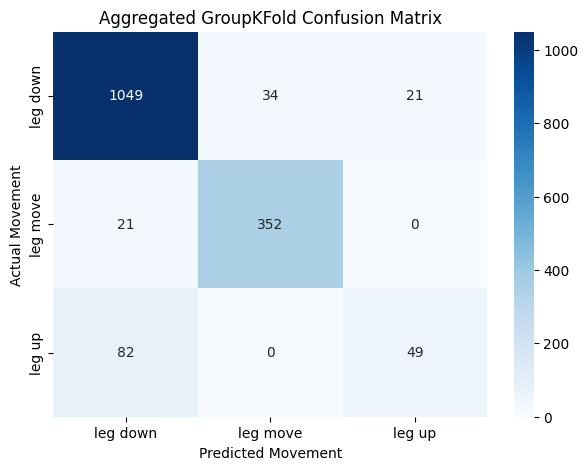

In [15]:
# Plot aggregated Confusion Matrix
cm = confusion_matrix(all_y_test, all_y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Aggregated GroupKFold Confusion Matrix')
plt.ylabel('Actual Movement')
plt.xlabel('Predicted Movement')
plt.show()

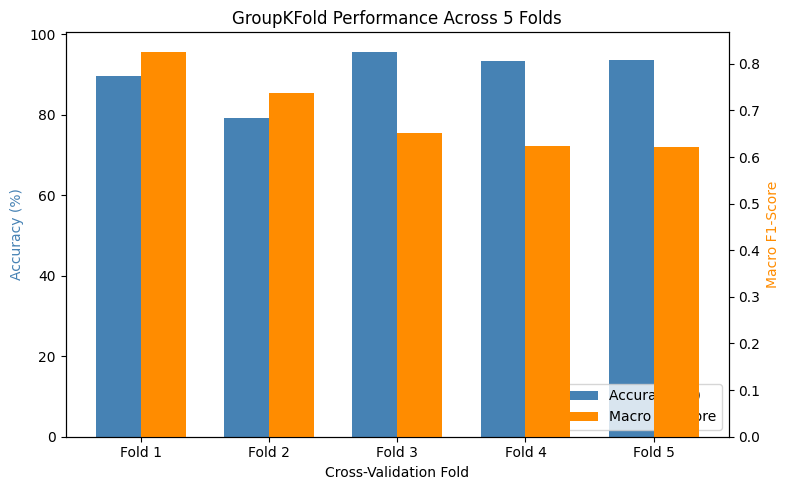

In [16]:


folds = np.arange(1, len(accuracies) + 1)
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

rects1 = ax1.bar(folds - bar_width/2, [acc * 100 for acc in accuracies], bar_width, label='Accuracy (%)', color='steelblue')

ax2 = ax1.twinx()
rects2 = ax2.bar(folds + bar_width/2, f1_scores, bar_width, label='Macro F1-Score', color='darkorange')

ax1.set_xlabel('Cross-Validation Fold')
ax1.set_ylabel('Accuracy (%)', color='steelblue')
ax2.set_ylabel('Macro F1-Score', color='darkorange')
plt.title('GroupKFold Performance Across 5 Folds')
ax1.set_xticks(folds)
ax1.set_xticklabels([f'Fold {i}' for i in folds])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.show()

Generating Feature Importance Chart...


C:\Users\Fahad\AppData\Local\Temp\ipykernel_33756\2978249739.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


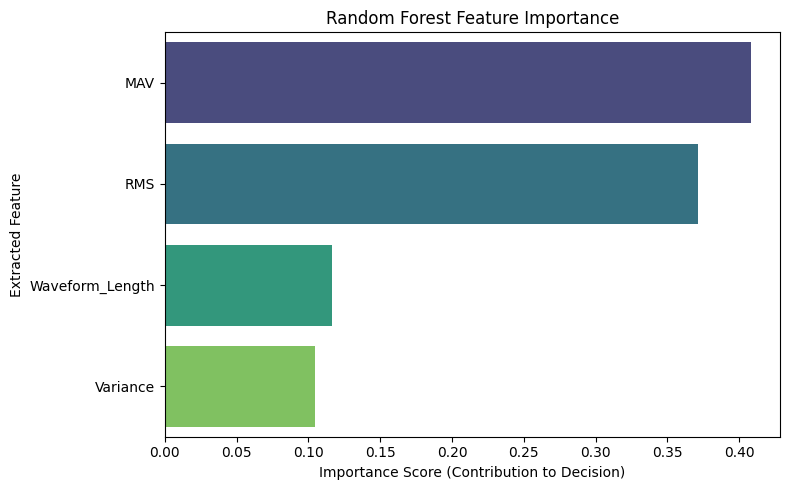

In [17]:

print("Generating Feature Importance Chart...")

importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score (Contribution to Decision)')
plt.ylabel('Extracted Feature')
plt.tight_layout()

plt.show()

In [22]:
joblib.dump(model, 'emg_random_forest_model.pkl')
X_test.head(10).to_pickle('sample_test_stream.pkl')

print("Model and test stream successfully saved for the bonus task!")

Model and test stream successfully saved for the bonus task!
